# Stochastic Optimization Tutorial

Try it out yourself:
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/jbussemaker/SBArchOpt/HEAD?labpath=docs%2Ftutorial_stochastic.ipynb)

This tutorial takes `MDMOHimmelblau`, the mixed-discrete multi-objective Himmelblau test problem, and turns it into a stochastic problem by assuming that the continuous design variable cannot be measured accurately. This uncertainty is modeled by adding a perturbation to the variable, represented by a zero-mean Gaussian distribution. The tutorial then compares the robust Pareto fronts found by NSGA2 and SBO with the deterministic one. For more background information, refer to the [documentation](../algo/stochastic).

**Note**: make sure you have installed the `uncertainty` and `arch_sbo` dependencies:
```
pip install sb-arch-opt[uncertainty,arch_sbo]
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

## The Stochastic Problem Class

Stochastic optimization problems in SBArchOpt are defined by extending the `sb_arch_opt.stochastic_problem.StochasticArchOptProblem` class, which itself extends `ArchOptProblemBase`. Three things are defined on top of the design variables:
- A `StochasticParameterSpace`: the joint distribution of the uncertain parameters. These influence the evaluation but are not chosen by the optimizer, and therefore are NOT design variables.
- A `UQMethod` (`MonteCarlo` or `PolynomialChaos`): which realizations to evaluate, and how to turn the responses into statistics. It is given a budget of `n_evaluations` evaluations per design point.
- A `Scalarization` per objective and constraint (`Mean`, `Margin` or `Quantile`): which statistic of the response the optimizer sees. Here the default `Mean` is used, so the expected value of each objective is minimized.

Evaluation is implemented in `_arch_evaluate_sample` instead of `_arch_evaluate`: this function is called once per realization of the uncertain parameters, receives that realization in `parameters`, and writes the responses for that realization only. The loop over realizations and the reduction to the values the optimizer sees are owned by the base class.

Below, `MDMOHimmelblau` is wrapped in such a class: its continuous design variable is realized with a normally-distributed deviation from its nominal value, and the underlying problem is then evaluated at the realized design vector. Since the design space of the underlying problem is reused, the design variables and the correction of design vectors are inherited as-is and `_correct_x` does not need to be implemented.

In [2]:
import numpy as np
import openturns as ot
from sb_arch_opt.problems.md_mo import MDMOHimmelblau
from sb_arch_opt.stochastic_problem import StochasticArchOptProblem
from sb_arch_opt.uncertainty import MonteCarlo, StochasticParameter, StochasticParameterSpace


class StochasticMDMOHimmelblau(StochasticArchOptProblem):
    """MDMOHimmelblau where the continuous design variable is realized with a manufacturing tolerance"""

    def __init__(self, std=.3, n=1000, seed=42, obj_scalar=None):
        self._problem = MDMOHimmelblau()
        self.std = std

        # One uncertain parameter per continuous design variable: the deviation from its nominal value
        self._i_cont = np.where(~self._problem.is_discrete_mask)[0]
        param_space = StochasticParameterSpace([
            StochasticParameter(f'dx{i}', ot.Normal(0., std)) for i in self._i_cont])

        super().__init__(
            self._problem.design_space,  # Same design space, so the same variables and correction
            param_space=param_space,
            uq_method=MonteCarlo(n_evaluations=n, seed=seed),
            n_obj=self._problem.n_obj, obj_scalar=obj_scalar,
        )

    def _arch_evaluate_sample(self, x, is_active, f_out, g_out, h_out, parameters, *args, **kwargs):
        # Called once per realization: apply the deviations and evaluate the underlying problem
        x_realized = x.copy()
        x_realized[:, self._i_cont] += parameters

        f_out[:, :] = self._problem.evaluate(x_realized, return_as_dictionary=True)['F']

    def __repr__(self):
        return f'{self.__class__.__name__}(std={self.std}, n={self.uq_method.n_evaluations})'

In [3]:
# Instantiate the problem class and print some statistics
problem = StochasticMDMOHimmelblau(std=.3, n=1000)
problem.print_stats()

problem: StochasticMDMOHimmelblau(std=0.3, n=1000)
n_discr: 1
n_cont : 1
n_obj  : 2
n_con  : 0
MD     : True
MO     : True
HIER         : False
n_valid_discr: 10
imp_ratio    : 1.00 (discr.: 1.00; cont.: 1.00)
corr_ratio   : 1.00 (discr.: 1.00; cont.: 1.00; fraction of imp_ratio: 0.0%)
stochastic   : True
n_params     : 1
uq_method    : Monte Carlo
n_evaluations: 1000
obj          : [Mean, Mean]
ieq_constr   : []
ieq_constr   : []


The resulting problem has the same design variables and objectives as the deterministic one, only the evaluation has changed. Note that one design point now costs 1000 evaluations of the underlying problem, which is what makes Surrogate-Based Optimization (SBO) especially relevant for stochastic problems.

## Solving with NSGA2

The stochastic problem is an `ArchOptProblemBase` subclass, so the algorithms in SBArchOpt can be used without modification. The code below runs the pre-configured NSGA2 and compares the resulting robust Pareto front to the known deterministic Pareto front of `MDMOHimmelblau`.

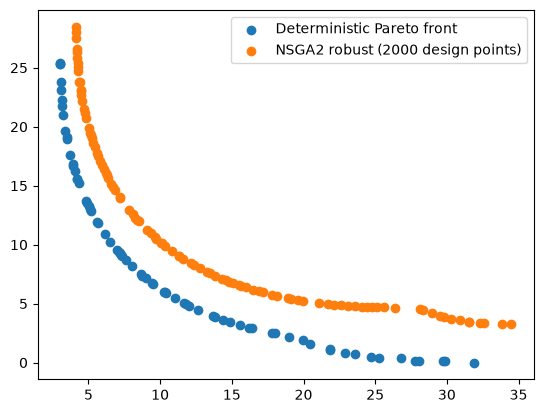

In [4]:
from pymoo.optimize import minimize
from sb_arch_opt.algo.pymoo_interface import plot, get_nsga2

# Create the pre-configured NSGA2 algorithm
nsga2 = get_nsga2(pop_size=100)

# Run the optimization: 20 generations (20 x 100 = 2000 design points, each with 50 realizations)
# NOTE: remove "seed" argument when using in production!
result_nsga2 = minimize(problem, nsga2, termination=('n_gen', 20), seed=42)

# Compare the robust Pareto front to the deterministic one
pf_deterministic = MDMOHimmelblau().pareto_front()
plot(pf_deterministic, result_nsga2.opt.get('F'),
     labels=['Deterministic Pareto front', 'NSGA2 robust (2000 design points)'])

The robust Pareto front lies above the deterministic one, which clealry shows that the perturbation in design vector has effect on the objectives. The deterministic front is therefore not achievable in practice, and optimizing towards it would select designs that are more sensitive to the perturbations.

## Solving with SBO

Because every design point requires 1000 evaluations for each sample realization, the number of design points for evaluation should be kept low. Surrogate-Based Optimization (SBO) in general requires less evaluations than genetic algorithms to find the Pareto front, therefore they are well suited for the stochastic optimization problems.

INFO     2026-09-23 15:43:57,897 sb_arch_opt.sbo   : Surrogate infill gen 10 @ 1000 points evaluated (20 real unique, 20 eval)


INFO     2026-09-23 15:43:58,006 sb_arch_opt.sbo   : Infill: 4 new (eval 20 real unique, 20 eval)


INFO     2026-09-23 15:43:58,979 sb_arch_opt.sbo   : Surrogate infill gen 10 @ 1000 points evaluated (24 real unique, 24 eval)


INFO     2026-09-23 15:43:59,077 sb_arch_opt.sbo   : Infill: 4 new (eval 24 real unique, 24 eval)


INFO     2026-09-23 15:44:05,862 sb_arch_opt.sbo   : Surrogate infill gen 10 @ 1000 points evaluated (28 real unique, 28 eval)


...

INFO     2026-09-23 15:44:09,584 sb_arch_opt.sbo   : Infill: 4 new (eval 40 real unique, 40 eval)


INFO     2026-09-23 15:44:10,589 sb_arch_opt.sbo   : Surrogate infill gen 10 @ 1000 points evaluated (44 real unique, 44 eval)


INFO     2026-09-23 15:44:10,933 sb_arch_opt.sbo   : Infill: 4 new (eval 44 real unique, 44 eval)


INFO     2026-09-23 15:44:12,005 sb_arch_opt.sbo   : Surrogate infill gen 10 @ 1000 points evaluated (48 real unique, 48 eval)


INFO     2026-09-23 15:44:12,305 sb_arch_opt.sbo   : Infill: 4 new (eval 48 real unique, 48 eval)


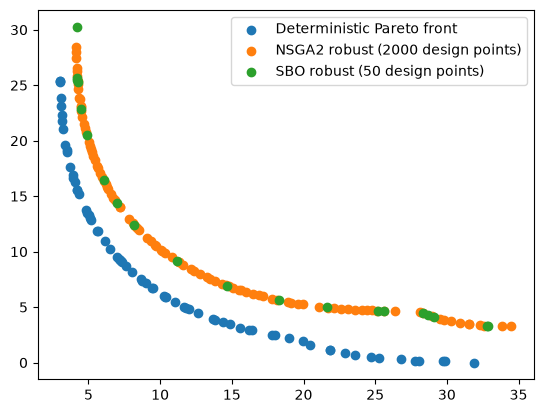

In [5]:
from sb_arch_opt.algo.arch_sbo.api import get_arch_sbo_gp

# Create the algorithm (with an initial database size of 20)
n_init = 20
sbo = get_arch_sbo_gp(problem, n_parallel=4, init_size=n_init)

# Run the optimization: 30 infill points (20 + 30 = 50 design points)
# NOTE: remove "seed" argument when using in production!
n_infill = 30
result_sbo = minimize(problem, sbo, termination=('n_eval', n_init+n_infill), seed=42)

# Compare both robust Pareto fronts to the deterministic one
plot(pf_deterministic, result_nsga2.opt.get('F'), result_sbo.opt.get('F'),
     labels=['Deterministic Pareto front', 'NSGA2 robust (2000 design points)',
             'SBO robust (50 design points)'])

SBO reaches the same robust Pareto front as NSGA2 using 40 times fewer design points. Given that for each design points 1000 evaluations are performed to propagate uncertainty, the computational budget savings are tremendous compared with NSGA-2 (overall 40,000 less evaluations).